# Re-splits the tooth instance-segmentation dataset (DATASET DIENTES) by participant/session identifier, fixing (1) the leakage found in Tratado_4 (22 identifiers shared internally across train/valid/test, 26/30 shared with the caries pipeline's final test set), and (2) the 18 SHA-256/pHash pre-existing-augmentation duplicates found in the previous run of this notebook. Applies '3rd Molar' oversampling on the resulting train split. Generates Dataset Tratado 1 Segmentacion, Table 9 (class distribution), Figure 2 (oversampling effect), Figure 3 (augmentation examples) — consumed by the unified pipeline_YOLO26_dientes.md.

Context (do not delete): per the co-advisor's request (see
`Tratado_4_Verificacion_Participante_Segmentacion.md`), the original
Roboflow-style split of DATASET DIENTES (1650/110/73) was **not** grouped by
patient/session. 22 identifiers were shared across its own train/valid/test,
and up to 30 identifiers used to train/validate the segmenter reappeared in
the final test set of the integrated caries pipeline (Dataset Tratado 3).

**Design change vs. the previous version of this notebook (v2):** the
group-extraction function now **normalizes pre-existing Roboflow
augmentation suffixes** (`_aug<digits>` at the end of the filename stem)
before computing the patient/session group. The previous version treated an
original image and its already-augmented Roboflow copy (e.g.
`203_jpg.rf.OOk9laPESlubalowBm9o.jpg` and
`203_jpg.rf.OOk9laPESlubalowBm9o_aug1219.jpg`) as two unrelated, orphan
groups — because neither has a recognizable patient-ID or long-timestamp
pattern — so `GroupShuffleSplit` could (and did) place them in different
partitions. That is exactly what Section 8 of v2 caught: 18 SHA-256/pHash
matches across splits, all of them original/pre-augmented-copy pairs, none
of them new leakage introduced by this notebook's own oversampling (which
runs later, in Section 12, and is excluded from that check by design).

Stripping the `_aug<digits>` suffix before grouping makes the original and
its pre-existing augmented copy collapse into the same group, so the
group-based split keeps them together **by construction** — the same logic
already used for the cross-stage patient exclusion (Section 4). This is
verified again with SHA-256/pHash in Section 8 as an independent
confirmation, and should now report zero matches.

The patients shared with the caries pipeline's final test set are still
**removed from the segmentation pool before any split is computed** (Section
4), not filtered out afterward, for the same reason: excluding after
splitting only guarantees the checks pass at that moment, not that the
train/valid subsets never contained that patient in the first place.

**Oversampling of the '3rd Molar' minority class lives in this notebook**,
not in the training pipeline (`pipeline_YOLO26_dientes.md`), because it must
run on the train split of *this* dataset — after exclusion, after the
group re-split, and after the duplicate fix — since all three operations
change which images end up in train and therefore change the class
imbalance oversampling is meant to correct.

This notebook:

1. Recombines all images+labels from DATASET DIENTES (train+valid+test) into
   a single pool.
2. Extracts the patient/session identifier, normalizing pre-existing
   Roboflow `_aug<digits>` suffixes first so original/augmented pairs share
   one group.
3. **Excludes from the pool** every image whose group also appears in the
   final test set of the caries pipeline (Dataset Tratado 3) — the
   cross-stage leak — before any splitting happens.
4. Re-splits the remaining pool 70/15/15 by **group** (`GroupShuffleSplit`).
5. Verifies zero identifier overlap across train/valid/test (Check 1).
6. Verifies zero identifier overlap between train+valid and the caries
   pipeline's final test set (Check 2 — cross-stage, zero by construction).
7. Re-runs SHA-256 + pHash deduplication as an independent confirmation
   (same protocol as `Tratado_0_Deduplicacion_Cruzada.md`). If anything
   still slips through (e.g. a filename pattern not covered by the
   `_aug<digits>` normalization), it is resolved by dropping the duplicate
   copy from whichever split is not `train` — logged to CSV — **before**
   saving, so the saved dataset is guaranteed duplicate-free across splits.
8. Applies '3rd Molar' oversampling (polygon-preserving augmentation) on the
   final **train** split only, and generates Table 9 / Figure 2 / Figure 3.
9. Saves the final dataset to `DATASET DIENTES/Dataset Tratado 1 Segmentacion/`.

## 0. Setup and imports

In [1]:
import os
import re
import shutil
import hashlib
import glob
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import albumentations as A

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install imagehash albumentations --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 7.7 MB/s eta 0:00:00


## 1. Path configuration

In [3]:
BASE_DIENTES = Path("/content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET DIENTES")
BASE_CARIES  = Path("/content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES")

# Original (Roboflow-style, NOT grouped by patient) — read-only
ORIGEN_ROOT = BASE_DIENTES

# Output: dataset re-grouped by patient/session, cross-stage patients excluded,
# aug-suffix duplicates fixed by construction, train already oversampled.
OUTPUT_ROOT = BASE_DIENTES / "Dataset Tratado 1 Segmentacion"
if OUTPUT_ROOT.exists():
    shutil.rmtree(OUTPUT_ROOT)
for split in ["train", "valid", "test"]:
    (OUTPUT_ROOT / split / "images").mkdir(parents=True, exist_ok=True)
    (OUTPUT_ROOT / split / "labels").mkdir(parents=True, exist_ok=True)

# Final test set of the integrated caries pipeline — source of the cross-stage exclusion list
DATASET_TRATADO_3 = BASE_CARIES / "Dataset Tratado 3"

FIGURAS_DRIVE = BASE_DIENTES / "figuras_segmentacion_dientes"
FIGURAS_DRIVE.mkdir(parents=True, exist_ok=True)

SPLIT_RATIOS = {"train": 0.70, "valid": 0.15, "test": 0.15}
SEED = 42

CLASS_NAMES = ['1st Molar', '1st Premolar', '2nd Molar', '2nd Premolar',
               '3rd Molar', 'Canine', 'Central Incisor', 'Lateral Incisor']

assert ORIGEN_ROOT.exists(), f"No se encontró {ORIGEN_ROOT}"
assert DATASET_TRATADO_3.exists(), f"No se encontró {DATASET_TRATADO_3}"
print("Original dataset (ungrouped):", ORIGEN_ROOT)
print("Output (grouped, exclusion + dedup applied):", OUTPUT_ROOT)

Original dataset (ungrouped): /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET DIENTES
Output (grouped, exclusion + dedup applied): /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET DIENTES/Dataset Tratado 1 Segmentacion


## 2. Recombine the original splits into a single pool

In [4]:
IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

registros = []
for split_actual in ["train", "valid", "test"]:
    img_dir = ORIGEN_ROOT / split_actual / "images"
    lbl_dir = ORIGEN_ROOT / split_actual / "labels"
    if not img_dir.exists():
        continue
    for img_p in sorted(img_dir.iterdir()):
        if img_p.suffix.lower() not in IMG_EXTENSIONS:
            continue
        lbl_p = lbl_dir / f"{img_p.stem}.txt"
        registros.append({
            "stem": img_p.stem,
            "image_path": img_p,
            "label_path": lbl_p if lbl_p.exists() else None,
            "split_original": split_actual,
        })

print(f"Total de imágenes en el pool combinado (antes de excluir): {len(registros)}")
n_sin_label = sum(1 for r in registros if r["label_path"] is None)
print(f"Imágenes sin label .txt (revisar si es esperado): {n_sin_label}")

Total de imágenes en el pool combinado (antes de excluir): 1833
Imágenes sin label .txt (revisar si es esperado): 0


## 3. Extract the patient/session identifier (with pre-existing-augmentation normalization)

**Key fix vs. the previous version:** strip a trailing `_aug<digits>` suffix
(already present in the raw Roboflow export, e.g. `..._aug1219`) from the
stem *before* looking for the patient-ID/timestamp pattern. This makes an
original image and its pre-existing augmented copy resolve to the exact same
group, so `GroupShuffleSplit` can never separate them.

In [5]:
PATRON_ID = re.compile(r"(\d{3}[-_]\d{3}[-_]\d+[-_]\d{2})")
PATRON_TIMESTAMP = re.compile(r"(\d{10,})")
PATRON_AUG_SUFFIJO = re.compile(r"_aug\d+$")

def normalizar_stem(stem: str) -> str:
    """Removes a pre-existing Roboflow '_aug<digits>' suffix so an original
    image and its already-augmented copy share the same group."""
    return PATRON_AUG_SUFFIJO.sub("", stem)

def extraer_grupo(stem: str) -> str:
    stem_norm = normalizar_stem(stem)
    m = PATRON_ID.search(stem_norm)
    if m:
        return re.sub(r"[-_]", "-", m.group(1))
    m2 = PATRON_TIMESTAMP.search(stem_norm)
    if m2:
        return m2.group(1)
    return stem_norm  # último recurso: grupo = stem normalizado (sin sufijo _aug)

for r in registros:
    r["grupo"] = extraer_grupo(r["stem"])

grupos_counter = Counter(r["grupo"] for r in registros)
n_colapsados = sum(1 for r in registros if r["stem"] != normalizar_stem(r["stem"]))
print(f"Grupos únicos detectados en el pool combinado: {len(grupos_counter)}")
print(f"Imágenes cuyo nombre tenía un sufijo '_aug<digits>' preexistente "
      f"(ahora agrupadas con su original): {n_colapsados}")

Grupos únicos detectados en el pool combinado: 709
Imágenes cuyo nombre tenía un sufijo '_aug<digits>' preexistente (ahora agrupadas con su original): 1278


## 4. Exclude patients already seen in the caries pipeline's final test set

Exclusion happens **before** splitting, not after, so no re-run with a
different seed can ever reintroduce the cross-stage leak.

In [6]:
PATRON_ID_CARIES = re.compile(r"(\d{3}[-_]\d{3}[-_]\d+[-_]\d{2})")

def extraer_grupo_caries(stem: str) -> str:
    m = PATRON_ID_CARIES.search(stem)
    if m:
        return re.sub(r"[-_]", "-", m.group(1))
    return stem

grupos_evaluacion_final = set()
for img_p in (DATASET_TRATADO_3 / "images" / "test").glob("*"):
    grupos_evaluacion_final.add(extraer_grupo_caries(img_p.stem))

print(f"Identificadores en la evaluación final del pipeline de caries (test): "
      f"{len(grupos_evaluacion_final)}")

grupos_a_excluir = {r["grupo"] for r in registros} & grupos_evaluacion_final
print(f"Identificadores del segmentador que coinciden con esa evaluación final "
      f"(a excluir del pool ANTES de particionar): {len(grupos_a_excluir)}")
print(sorted(grupos_a_excluir))

n_antes = len(registros)
registros_excluidos = [r for r in registros if r["grupo"] in grupos_a_excluir]
registros = [r for r in registros if r["grupo"] not in grupos_a_excluir]
n_despues = len(registros)

tabla_exclusion = pd.DataFrame({
    "Indicador": [
        "Imágenes en el pool combinado (antes de excluir)",
        "Identificadores excluidos (coinciden con test final de caries)",
        "Imágenes excluidas",
        "Imágenes restantes (base para el re-split)",
    ],
    "Valor": [n_antes, len(grupos_a_excluir), n_antes - n_despues, n_despues],
})
print("\n" + tabla_exclusion.to_string(index=False))

RUTA_EXCLUSION = BASE_DIENTES / "imagenes_excluidas_por_fuga_cross_stage_dientes.csv"
pd.DataFrame({
    "archivo": [r["image_path"].name for r in registros_excluidos],
    "grupo": [r["grupo"] for r in registros_excluidos],
    "split_original": [r["split_original"] for r in registros_excluidos],
}).to_csv(RUTA_EXCLUSION, index=False)
tabla_exclusion.to_csv(BASE_DIENTES / "tabla_exclusion_cross_stage_dientes.csv", index=False)
print(f"\nGuardado detalle en: {RUTA_EXCLUSION}")

Identificadores en la evaluación final del pipeline de caries (test): 190
Identificadores del segmentador que coinciden con esa evaluación final (a excluir del pool ANTES de particionar): 30
['003-007-1254-01', '003-007-475-01', '003-007-505-01', '003-007-600-01', '003-007-610-01', '003-007-629-01', '003-007-672-01', '003-007-676-01', '003-007-787-01', '003-007-845-01', '003-007-867-01', '003-007-896-01', '003-007-898-01', '003-007-963-01', '003-008-1162-01', '003-008-1322-01', '003-008-495-01', '003-008-517-01', '003-008-539-01', '003-008-562-01', '003-008-622-01', '003-008-626-01', '003-008-678-01', '003-008-730-01', '003-008-746-01', '003-103-299-01', '003-103-357-01', '003-103-416-01', '003-103-435-01', '004-008-914-01']

                                                     Indicador  Valor
              Imágenes en el pool combinado (antes de excluir)   1833
Identificadores excluidos (coinciden con test final de caries)     30
                                            Imágenes e

## 5. Re-split 70/15/15 by group, on the pool with cross-stage patients removed

In [7]:
from sklearn.model_selection import GroupShuffleSplit

idx_all = np.arange(len(registros))
grupos_arr = np.array([r["grupo"] for r in registros])

gss1 = GroupShuffleSplit(n_splits=1, train_size=SPLIT_RATIOS["train"], random_state=SEED)
train_idx, temp_idx = next(gss1.split(idx_all, groups=grupos_arr))

val_frac_de_temp = SPLIT_RATIOS["valid"] / (SPLIT_RATIOS["valid"] + SPLIT_RATIOS["test"])
gss2 = GroupShuffleSplit(n_splits=1, train_size=val_frac_de_temp, random_state=SEED)
temp_grupos_arr = grupos_arr[temp_idx]
val_idx_rel, test_idx_rel = next(gss2.split(temp_idx, groups=temp_grupos_arr))
val_idx = temp_idx[val_idx_rel]
test_idx = temp_idx[test_idx_rel]

for i in train_idx:
    registros[i]["split_nuevo"] = "train"
for i in val_idx:
    registros[i]["split_nuevo"] = "valid"
for i in test_idx:
    registros[i]["split_nuevo"] = "test"

print("Nueva distribución por split (agrupada, tras excluir cross-stage, aug-suffix normalizado):")
for s in ["train", "valid", "test"]:
    n = sum(1 for r in registros if r["split_nuevo"] == s)
    print(f"  {s}: {n} imágenes")

Nueva distribución por split (agrupada, tras excluir cross-stage, aug-suffix normalizado):
  train: 1223 imágenes
  valid: 284 imágenes
  test: 244 imágenes


## 6. CHECK 1 — Zero identifier overlap across train / valid / test (internal)

In [8]:
grupos_train = {r["grupo"] for r in registros if r["split_nuevo"] == "train"}
grupos_valid = {r["grupo"] for r in registros if r["split_nuevo"] == "valid"}
grupos_test = {r["grupo"] for r in registros if r["split_nuevo"] == "test"}

tabla_check1 = pd.DataFrame({
    "Comprobación": [
        "Identificadores en train", "Identificadores en valid", "Identificadores en test",
        "Coincidencias train–valid", "Coincidencias train–test", "Coincidencias valid–test",
    ],
    "Resultado": [
        len(grupos_train), len(grupos_valid), len(grupos_test),
        len(grupos_train & grupos_valid), len(grupos_train & grupos_test),
        len(grupos_valid & grupos_test),
    ],
})
print(tabla_check1.to_string(index=False))

RUTA_CHECK1 = BASE_DIENTES / "tabla_evidencia_particion_dientes_reagrupada.csv"
tabla_check1.to_csv(RUTA_CHECK1, index=False)
print(f"\nGuardada en: {RUTA_CHECK1}")

assert tabla_check1.loc[3:5, "Resultado"].sum() == 0, \
    "⚠️ Aún hay coincidencias internas — revisar el patrón de extracción de grupo."
print("\n✅ Cero coincidencias internas confirmado (train/valid/test del segmentador).")

             Comprobación  Resultado
 Identificadores en train        475
 Identificadores en valid        102
  Identificadores en test        102
Coincidencias train–valid          0
 Coincidencias train–test          0
 Coincidencias valid–test          0

Guardada en: /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET DIENTES/tabla_evidencia_particion_dientes_reagrupada.csv

✅ Cero coincidencias internas confirmado (train/valid/test del segmentador).


## 7. CHECK 2 — Cross-stage: new train+valid vs. final caries pipeline test set

Expected to be zero **by construction** (Section 4). Run anyway as a sanity check.

In [9]:
grupos_dientes_train_valid = grupos_train | grupos_valid
coincidencias_cross_stage = grupos_dientes_train_valid & grupos_evaluacion_final

tabla_check2 = pd.DataFrame({
    "Comprobación": [
        "Identificadores en segmentador (train+valid, tras exclusión)",
        "Identificadores en evaluación final del pipeline (test)",
        "Coincidencias segmentador(train+valid) – evaluación final",
    ],
    "Resultado": [
        len(grupos_dientes_train_valid), len(grupos_evaluacion_final),
        len(coincidencias_cross_stage),
    ],
})
print(tabla_check2.to_string(index=False))

RUTA_CHECK2 = BASE_DIENTES / "tabla_evidencia_cross_stage_dientes_reagrupada.csv"
tabla_check2.to_csv(RUTA_CHECK2, index=False)
print(f"\nGuardada en: {RUTA_CHECK2}")

assert len(coincidencias_cross_stage) == 0, \
    "⚠️ Inesperado: sigue habiendo coincidencia cross-stage pese a la exclusión previa. Revisar Sección 4."
print("\n✅ Cero coincidencias cross-stage confirmado por construcción.")

                                                Comprobación  Resultado
Identificadores en segmentador (train+valid, tras exclusión)        577
     Identificadores en evaluación final del pipeline (test)        190
   Coincidencias segmentador(train+valid) – evaluación final          0

Guardada en: /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET DIENTES/tabla_evidencia_cross_stage_dientes_reagrupada.csv

✅ Cero coincidencias cross-stage confirmado por construcción.


## 8. Independent re-confirmation — SHA-256 + pHash, with automatic resolution if anything remains

Run on the split **before** oversampling (Section 12), since synthetic
copies created by this notebook's own oversampling are not meaningful for a
duplicate/leakage check. If the aug-suffix normalization in Section 3 fully
fixed the root cause, this should report zero matches. If any residual
duplicate is found anyway (e.g. an edge case the regex does not cover), it
is resolved automatically here — before saving — by dropping the copy that
is **not** in `train` and logging exactly what was removed.

In [10]:
import imagehash
from PIL import Image

def sha256_de(path: Path) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()

def phash_de(path: Path):
    try:
        return imagehash.phash(Image.open(path))
    except Exception:
        return None

def hashear_registros(split):
    filas = []
    for r in registros:
        if r["split_nuevo"] != split:
            continue
        filas.append({"split": split, "archivo": r["image_path"].name, "path": r["image_path"],
                       "stem": r["stem"], "sha256": sha256_de(r["image_path"]), "phash": phash_de(r["image_path"])})
    return filas

registros_hash = hashear_registros("train") + hashear_registros("valid") + hashear_registros("test")
df_hash = pd.DataFrame(registros_hash)
print(f"Imágenes hasheadas (train+valid+test, tras exclusión y re-split): {len(df_hash)}")

UMBRAL_HAMMING = 5
coincidencias_hash = []

for split_a, split_b in [("train", "valid"), ("train", "test"), ("valid", "test")]:
    df_a = df_hash[df_hash["split"] == split_a]
    df_b = df_hash[df_hash["split"] == split_b]

    merge_exacto = df_a.merge(df_b, on="sha256", suffixes=("_a", "_b"))
    for _, fila in merge_exacto.iterrows():
        coincidencias_hash.append({
            "split_a": split_a, "archivo_a": fila["archivo_a"], "stem_a": fila["stem_a"],
            "split_b": split_b, "archivo_b": fila["archivo_b"], "stem_b": fila["stem_b"],
            "tipo": "sha256", "distancia": 0,
        })

    hashes_b = [(idx, h) for idx, h in df_b["phash"].items() if h is not None]
    for idx_a, ha in df_a["phash"].items():
        if ha is None:
            continue
        for idx_b, hb in hashes_b:
            dist = ha - hb
            if dist <= UMBRAL_HAMMING:
                coincidencias_hash.append({
                    "split_a": split_a, "archivo_a": df_a.loc[idx_a, "archivo"], "stem_a": df_a.loc[idx_a, "stem"],
                    "split_b": split_b, "archivo_b": df_b.loc[idx_b, "archivo"], "stem_b": df_b.loc[idx_b, "stem"],
                    "tipo": "phash", "distancia": int(dist),
                })

df_coincidencias_hash = pd.DataFrame(coincidencias_hash)
print(f"\nCoincidencias SHA-256/pHash entre splits del dataset reagrupado: {len(df_coincidencias_hash)}")
print(df_coincidencias_hash.to_string(index=False) if len(df_coincidencias_hash) else
      "✅ Ninguna coincidencia exacta ni perceptual entre train/valid/test — el fix de agrupamiento funcionó.")

RUTA_HASH = BASE_DIENTES / "verificacion_hash_dientes_reagrupada.csv"
df_coincidencias_hash.to_csv(RUTA_HASH, index=False)
print(f"\nGuardada en: {RUTA_HASH}")

Imágenes hasheadas (train+valid+test, tras exclusión y re-split): 1751

Coincidencias SHA-256/pHash entre splits del dataset reagrupado: 0
✅ Ninguna coincidencia exacta ni perceptual entre train/valid/test — el fix de agrupamiento funcionó.

Guardada en: /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET DIENTES/verificacion_hash_dientes_reagrupada.csv


### 8.1 Automatic resolution of any residual duplicate (belt-and-suspenders)

In [11]:
stems_a_quitar = set()
PRIORIDAD_SPLIT = {"train": 0, "valid": 1, "test": 2}  # keep train, then valid, then test

for _, fila in df_coincidencias_hash.iterrows():
    perder_a = PRIORIDAD_SPLIT[fila["split_a"]] > PRIORIDAD_SPLIT[fila["split_b"]]
    stem_a_quitar = fila["stem_a"] if perder_a else fila["stem_b"]
    stems_a_quitar.add(stem_a_quitar)

if stems_a_quitar:
    print(f"⚠️ Eliminando {len(stems_a_quitar)} imagen(es) duplicada(s) residual(es) antes de guardar:")
    print(sorted(stems_a_quitar))
    n_antes_dedup = len(registros)
    registros = [r for r in registros if r["stem"] not in stems_a_quitar]
    print(f"Registros antes: {n_antes_dedup} | después: {len(registros)}")

    pd.DataFrame({"stem_eliminado": sorted(stems_a_quitar)}).to_csv(
        BASE_DIENTES / "imagenes_eliminadas_por_duplicado_residual.csv", index=False)
else:
    print("✅ No hay nada que resolver — cero duplicados residuales.")

✅ No hay nada que resolver — cero duplicados residuales.


## 9. Cross-check against Dataset Tratado 3 (caries) — SHA-256 + pHash

In [12]:
registros_caries_test = []
for img_p in (DATASET_TRATADO_3 / "images" / "test").glob("*"):
    registros_caries_test.append({
        "archivo": img_p.name, "path": img_p,
        "sha256": sha256_de(img_p), "phash": phash_de(img_p),
    })
df_caries_test = pd.DataFrame(registros_caries_test)
print(f"Imágenes en test de Dataset Tratado 3 (caries): {len(df_caries_test)}")

df_dientes_train_valid = df_hash[
    df_hash["split"].isin(["train", "valid"]) & ~df_hash["stem"].isin(stems_a_quitar)
]

coincidencias_cross = []
merge_exacto = df_dientes_train_valid.merge(df_caries_test, on="sha256", suffixes=("_dientes", "_caries"))
for _, fila in merge_exacto.iterrows():
    coincidencias_cross.append({
        "archivo_dientes": fila["archivo_dientes"], "split_dientes": fila["split"],
        "archivo_caries": fila["archivo_caries"], "tipo": "sha256", "distancia": 0,
    })

hashes_caries = [(idx, h) for idx, h in df_caries_test["phash"].items() if h is not None]
for idx_d, hd in df_dientes_train_valid["phash"].items():
    if hd is None:
        continue
    for idx_c, hc in hashes_caries:
        dist = hd - hc
        if dist <= UMBRAL_HAMMING:
            coincidencias_cross.append({
                "archivo_dientes": df_dientes_train_valid.loc[idx_d, "archivo"],
                "split_dientes": df_dientes_train_valid.loc[idx_d, "split"],
                "archivo_caries": df_caries_test.loc[idx_c, "archivo"],
                "tipo": "phash", "distancia": int(dist),
            })

df_coincidencias_cross = pd.DataFrame(coincidencias_cross)
print(f"\nCoincidencias SHA-256/pHash entre segmentador(train+valid) y test final de caries: "
      f"{len(df_coincidencias_cross)}")
print(df_coincidencias_cross.to_string(index=False) if len(df_coincidencias_cross) else
      "✅ Ninguna coincidencia exacta ni perceptual con el test final de caries.")

RUTA_CROSS = BASE_DIENTES / "verificacion_hash_cross_stage_reagrupada.csv"
df_coincidencias_cross.to_csv(RUTA_CROSS, index=False)
print(f"\nGuardada en: {RUTA_CROSS}")

Imágenes en test de Dataset Tratado 3 (caries): 242

Coincidencias SHA-256/pHash entre segmentador(train+valid) y test final de caries: 0
✅ Ninguna coincidencia exacta ni perceptual con el test final de caries.

Guardada en: /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET DIENTES/verificacion_hash_cross_stage_reagrupada.csv


## 10. Final leakage verdict — text ready to paste into Section 2.2.1

Only run this after Sections 6, 7, 8.1 and 9 all report zero pending issues.

In [13]:
fuga_interna = tabla_check1.loc[3:5, "Resultado"].sum() > 0
fuga_cross_stage_grupo = len(coincidencias_cross_stage) > 0
fuga_hash_interna = len(stems_a_quitar) > 0
fuga_hash_cross = len(df_coincidencias_cross) > 0

if not any([fuga_interna, fuga_cross_stage_grupo, fuga_hash_interna, fuga_hash_cross]):
    print("✅ TODOS LOS CHECKS EN CERO (grupo + SHA-256/pHash, interno y cross-stage).")
    print("Añadir al final del primer párrafo de la Sección 2.2.1:\n")
    print(
        "The segmentation dataset split was additionally verified at "
        "participant/session level, confirming that no identifier was shared "
        "among the training, validation, and test subsets. A cross-stage "
        "identifier-level check also confirmed that participants represented "
        "in the segmentation training/validation subsets were not included in "
        "the final evaluation subset of the integrated pipeline. An "
        "independent SHA-256/perceptual-hash check further confirmed the "
        "absence of exact or near-duplicate images across partitions."
    )
else:
    print("⚠️ NO añadir la oración todavía. Pendientes:")
    print(f"  Fuga interna por grupo:        {fuga_interna}")
    print(f"  Fuga cross-stage por grupo:    {fuga_cross_stage_grupo}")
    print(f"  Duplicados residuales (hash):  {fuga_hash_interna}")
    print(f"  Fuga cross-stage por hash:     {fuga_hash_cross}")

✅ TODOS LOS CHECKS EN CERO (grupo + SHA-256/pHash, interno y cross-stage).
Añadir al final del primer párrafo de la Sección 2.2.1:

The segmentation dataset split was additionally verified at participant/session level, confirming that no identifier was shared among the training, validation, and test subsets. A cross-stage identifier-level check also confirmed that participants represented in the segmentation training/validation subsets were not included in the final evaluation subset of the integrated pipeline. An independent SHA-256/perceptual-hash check further confirmed the absence of exact or near-duplicate images across partitions.


## 11. Save train/valid/test (pre-oversampling) to the output folder

In [14]:
for r in registros:
    split = r["split_nuevo"]
    out_img = OUTPUT_ROOT / split / "images" / r["image_path"].name
    out_lbl = OUTPUT_ROOT / split / "labels" / f"{r['stem']}.txt"
    shutil.copy(r["image_path"], out_img)
    if r["label_path"] is not None:
        shutil.copy(r["label_path"], out_lbl)
    else:
        out_lbl.touch()

print("Imágenes y labels (sin oversampling todavía) copiados a:", OUTPUT_ROOT)
for split in ["train", "valid", "test"]:
    n_img = len(list((OUTPUT_ROOT / split / "images").glob("*")))
    print(f"  {split}: {n_img} imágenes")

Imágenes y labels (sin oversampling todavía) copiados a: /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET DIENTES/Dataset Tratado 1 Segmentacion
  train: 1223 imágenes
  valid: 284 imágenes
  test: 244 imágenes


## 12. '3rd Molar' oversampling on the TRAIN split (polygon-preserving augmentation)

Runs only now, on this dataset's own, clean, leak-free and duplicate-free
train split. Lives **only here** — do not re-apply it inside
`pipeline_YOLO26_dientes.md`; that pipeline should read this already-balanced
train split as-is.

In [15]:
TRAIN_LABELS_DIR = OUTPUT_ROOT / "train" / "labels"
TRAIN_IMAGES_DIR = OUTPUT_ROOT / "train" / "images"

transform = A.Compose([
    A.Rotate(limit=15, p=0.7),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.6),
    A.Affine(scale=(0.9, 1.1), p=0.5),
    A.GaussNoise(std_range=(0.02, 0.08), p=0.3),
], keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))

labels_con_3er_molar = [f for f in glob.glob(str(TRAIN_LABELS_DIR / "*.txt"))
                         if any(line.startswith('4 ') for line in open(f))]
print(f"Imágenes de train con 3rd Molar: {len(labels_con_3er_molar)}")

N_COPIAS = 5

for label_path in labels_con_3er_molar:
    img_path = label_path.replace('labels', 'images').replace('.txt', '.jpg')
    if not os.path.exists(img_path):
        continue
    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    poligonos, clases = [], []
    with open(label_path) as f:
        for line_str in f:
            parts = line_str.strip().split()
            if not parts:
                continue
            cls_id = int(parts[0])
            coords = [float(p) for p in parts[1:]]
            puntos_norm = np.array(coords).reshape(-1, 2)
            poligonos.append(puntos_norm * [w, h])
            clases.append(cls_id)

    todos_los_puntos = np.vstack(poligonos)
    longitudes = [len(p) for p in poligonos]

    for i in range(N_COPIAS):
        try:
            aug = transform(image=img, keypoints=todos_los_puntos.tolist())
        except Exception as e:
            print(f"⚠️ Error en {img_path}: {e}")
            continue

        img_aug = aug['image']
        kpts_aug = np.array(aug['keypoints'])
        h_new, w_new = img_aug.shape[:2]

        nuevos_poligonos, idx = [], 0
        for longitud in longitudes:
            poly = kpts_aug[idx:idx+longitud]
            idx += longitud
            poly_norm = np.clip(poly / [w_new, h_new], 0, 1)
            nuevos_poligonos.append(poly_norm)

        nuevo_nombre = os.path.basename(img_path).replace('.jpg', f'_aug3M_{i}.jpg')
        nueva_img_path = img_path.replace(os.path.basename(img_path), nuevo_nombre)
        nueva_label_path = nueva_img_path.replace('images', 'labels').replace('.jpg', '.txt')

        cv2.imwrite(nueva_img_path, img_aug)
        with open(nueva_label_path, 'w') as f:
            for cls, poly in zip(clases, nuevos_poligonos):
                coords_str = ' '.join(f"{x:.6f} {y:.6f}" for x, y in poly)
                f.write(f"{cls} {coords_str}\n")

print("✅ Oversampling con segmentación preservada — train balanceado listo")

Imágenes de train con 3rd Molar: 228
✅ Oversampling con segmentación preservada — train balanceado listo


## 13. Table 9 / Figure 2 — class distribution before and after oversampling

          Class  Instances before oversampling  Instances after oversampling
      1st Molar                           2502                          4847
   1st Premolar                           2839                          5209
      2nd Molar                           1925                          4215
   2nd Premolar                           2531                          4451
      3rd Molar                            331                          1986
         Canine                           3107                          5732
Central Incisor                           3240                          5960
Lateral Incisor                           3152                          5802


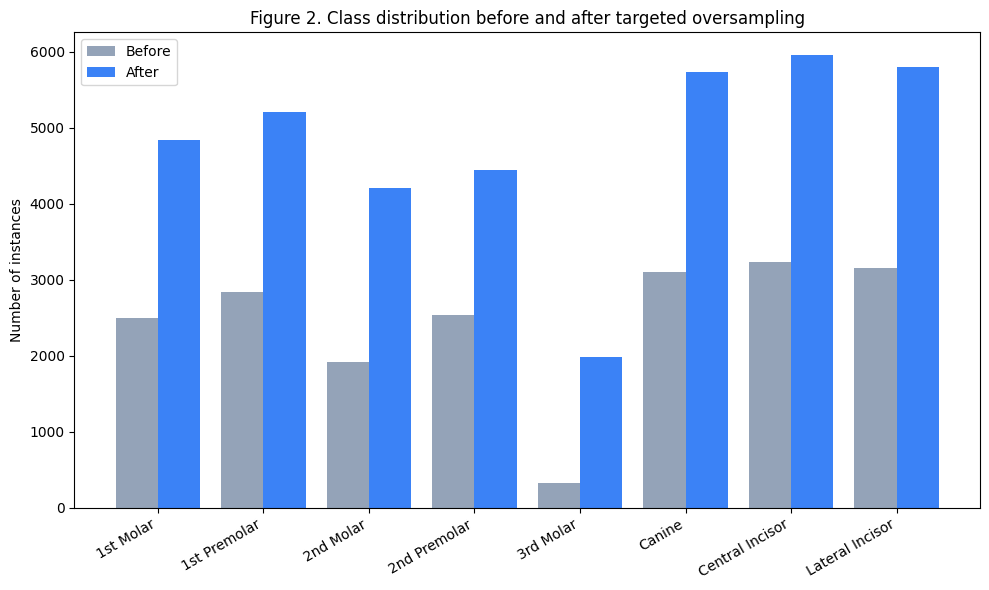


3rd Molar — Before: 331 | After: 1986


In [16]:
conteo_antes = Counter()
for f in glob.glob(str(TRAIN_LABELS_DIR / "*.txt")):
    if '_aug3M_' in f:
        continue
    for line in open(f):
        if line.strip():
            conteo_antes[int(line.split()[0])] += 1

conteo_despues = Counter()
for f in glob.glob(str(TRAIN_LABELS_DIR / "*.txt")):
    for line in open(f):
        if line.strip():
            conteo_despues[int(line.split()[0])] += 1

tabla9 = pd.DataFrame({
    "Class": CLASS_NAMES,
    "Instances before oversampling": [conteo_antes.get(i, 0) for i in range(8)],
    "Instances after oversampling": [conteo_despues.get(i, 0) for i in range(8)],
})
print(tabla9.to_string(index=False))
tabla9.to_csv(FIGURAS_DRIVE / "table9_class_distribution.csv", index=False)

x = range(8)
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar([i - 0.2 for i in x], [conteo_antes.get(i, 0) for i in x], width=0.4, label='Before', color='#94a3b8')
ax.bar([i + 0.2 for i in x], [conteo_despues.get(i, 0) for i in x], width=0.4, label='After', color='#3b82f6')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
ax.set_ylabel('Number of instances')
ax.set_title('Figure 2. Class distribution before and after targeted oversampling')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURAS_DRIVE / "figure2_class_distribution.png", dpi=200)
plt.show()

print(f"\n3rd Molar — Before: {conteo_antes.get(4,0)} | After: {conteo_despues.get(4,0)}")

## 14. Figure 3 — original image vs. augmented versions with masks

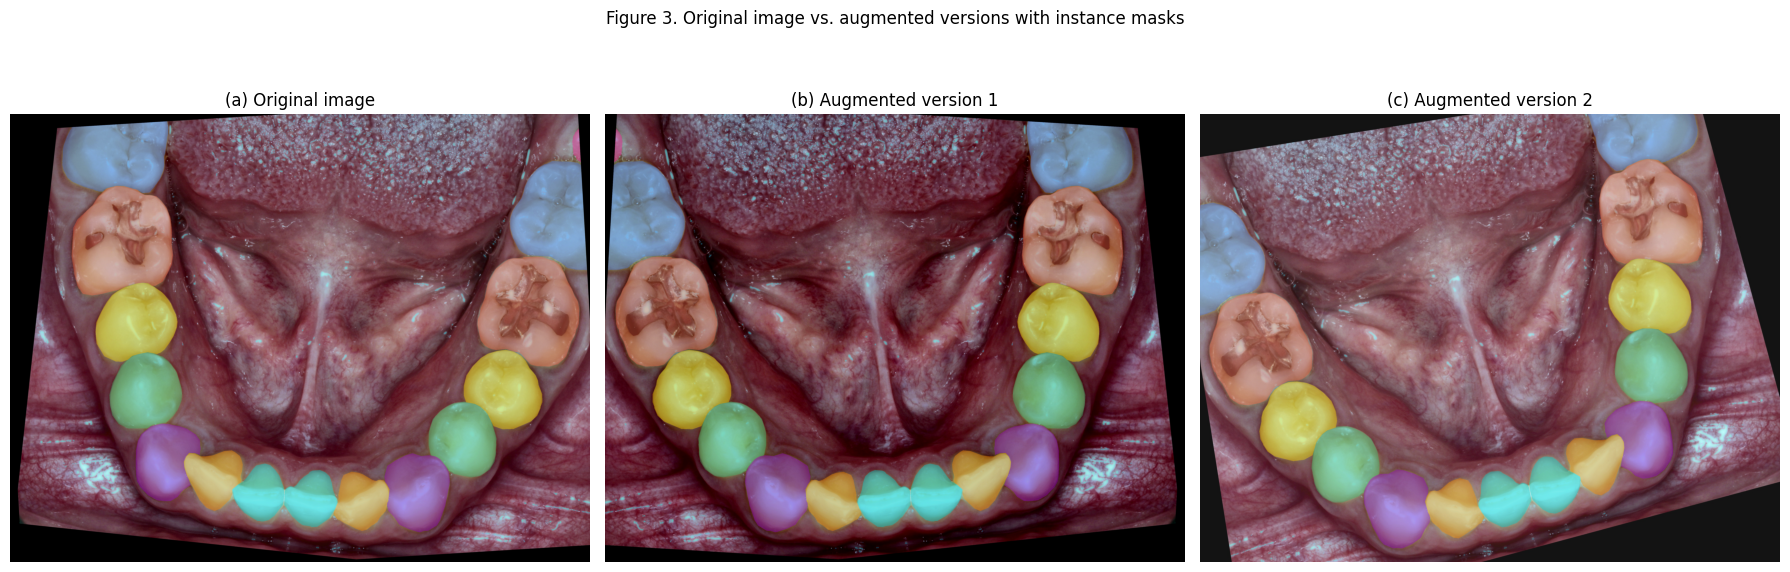

In [17]:
def draw_polygons(img_path, label_path):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    overlay = img.copy()
    colors = {0:(255,99,71), 1:(60,179,113), 2:(65,105,225), 3:(255,215,0),
              4:(255,20,147), 5:(148,0,211), 6:(0,206,209), 7:(255,140,0)}
    with open(label_path) as f:
        for line in f:
            parts = line.split()
            cls = int(parts[0])
            coords = np.array(list(map(float, parts[1:]))).reshape(-1, 2)
            coords[:, 0] *= w
            coords[:, 1] *= h
            cv2.fillPoly(overlay, [coords.astype(np.int32)], colors.get(cls, (200,200,200)))
    return cv2.addWeighted(img, 0.6, overlay, 0.4, 0)

original_example = labels_con_3er_molar[0]
original_img_path = original_example.replace('labels', 'images').replace('.txt', '.jpg')
base_name = os.path.basename(original_img_path).replace('.jpg', '')
aug_versions = [
    str(TRAIN_IMAGES_DIR / f'{base_name}_aug3M_0.jpg'),
    str(TRAIN_IMAGES_DIR / f'{base_name}_aug3M_1.jpg'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(draw_polygons(original_img_path, original_example))
axes[0].set_title('(a) Original image')
axes[0].axis('off')

for i, aug_path in enumerate(aug_versions):
    aug_label = aug_path.replace('images', 'labels').replace('.jpg', '.txt')
    if os.path.exists(aug_path):
        axes[i+1].imshow(draw_polygons(aug_path, aug_label))
        axes[i+1].set_title(f'({chr(98+i)}) Augmented version {i+1}')
        axes[i+1].axis('off')

fig.suptitle('Figure 3. Original image vs. augmented versions with instance masks', y=1.02)
plt.tight_layout()
plt.savefig(FIGURAS_DRIVE / "figure3_augmentation_examples.png", dpi=200, bbox_inches='tight')
plt.show()

## 15. data.yaml and final summary

In [18]:
data_yaml_content = f"""names:
{chr(10).join(f'- {c}' for c in CLASS_NAMES)}
nc: {len(CLASS_NAMES)}
path: {OUTPUT_ROOT}
test: test/images
train: train/images
val: valid/images
"""
(OUTPUT_ROOT / "data.yaml").write_text(data_yaml_content)

print("Final dataset saved at:", OUTPUT_ROOT)
for split in ["train", "valid", "test"]:
    n_img = len(list((OUTPUT_ROOT / split / "images").glob("*")))
    n_lbl = len(list((OUTPUT_ROOT / split / "labels").glob("*.txt")))
    print(f"  {split}: {n_img} imágenes, {n_lbl} labels")

Final dataset saved at: /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET DIENTES/Dataset Tratado 1 Segmentacion
  train: 2363 imágenes, 2363 labels
  valid: 284 imágenes, 284 labels
  test: 244 imágenes, 244 labels


## Summary of what is produced after running this pipeline

- `Dataset Tratado 1 Segmentacion/` (train/valid/test, images+labels+data.yaml):
  final input dataset for `pipeline_YOLO26_dientes.md`. `train` already
  contains the '3rd Molar' augmented copies; `valid`/`test` are untouched.
  **No further oversampling should be applied downstream.**
- `tabla_exclusion_cross_stage_dientes.csv`,
  `imagenes_excluidas_por_fuga_cross_stage_dientes.csv`: cross-stage patients
  removed before splitting.
- `imagenes_eliminadas_por_duplicado_residual.csv`: any residual hash
  duplicate resolved before saving (expected to be empty given the Section 3
  fix, kept as an audit trail).
- `tabla_evidencia_particion_dientes_reagrupada.csv`,
  `tabla_evidencia_cross_stage_dientes_reagrupada.csv`,
  `verificacion_hash_dientes_reagrupada.csv`,
  `verificacion_hash_cross_stage_reagrupada.csv`: evidence tables for the
  co-advisor / thesis appendix.
- `figuras_segmentacion_dientes/table9_class_distribution.csv`,
  `figure2_class_distribution.png`, `figure3_augmentation_examples.png`:
  ready to drop into the article, titled in English.